<a href="https://colab.research.google.com/github/prathameshmowade/Patern-Recognition-/blob/main/PR_5_CM53.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch

In [4]:
path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Dataset Path: /kaggle/input/customer-segmentation-tutorial-in-python


In [5]:
df = pd.read_csv(os.path.join(path, "Mall_Customers.csv"))

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [10]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

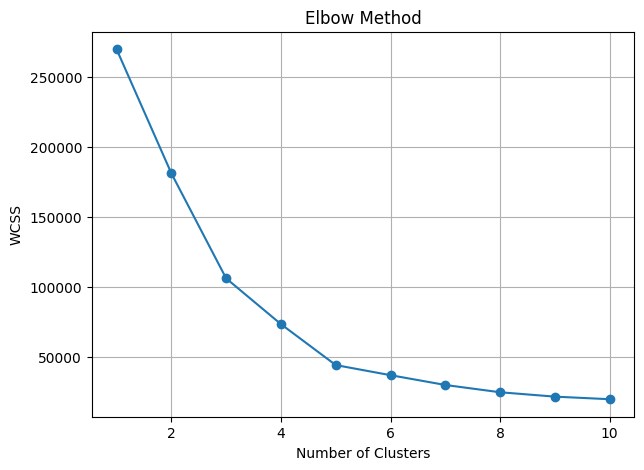

In [12]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [13]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X)

In [14]:
print(kmeans.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


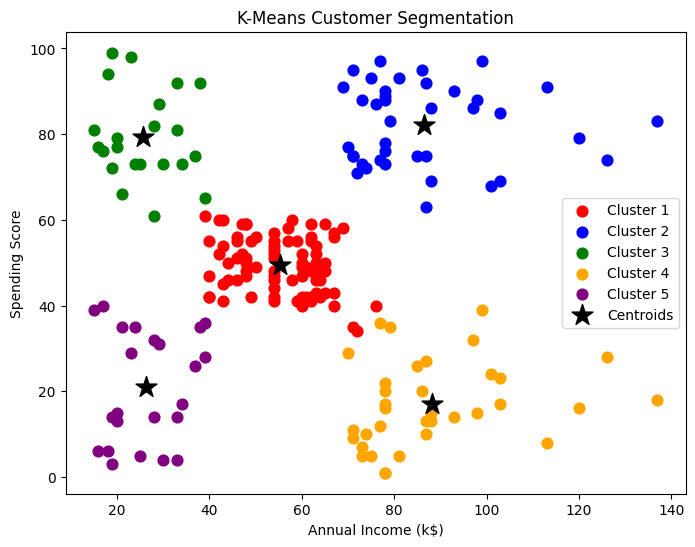

In [15]:
plt.figure(figsize=(8,6))

colors = ['red','blue','green','orange','purple']

for i in range(5):
    plt.scatter(
        X[y_kmeans == i,0],
        X[y_kmeans == i,1],
        s=60,
        color=colors[i],
        label=f'Cluster {i+1}'
    )

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=250,
    color='black',
    marker='*',
    label='Centroids'
)

plt.title("K-Means Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()

plt.show()

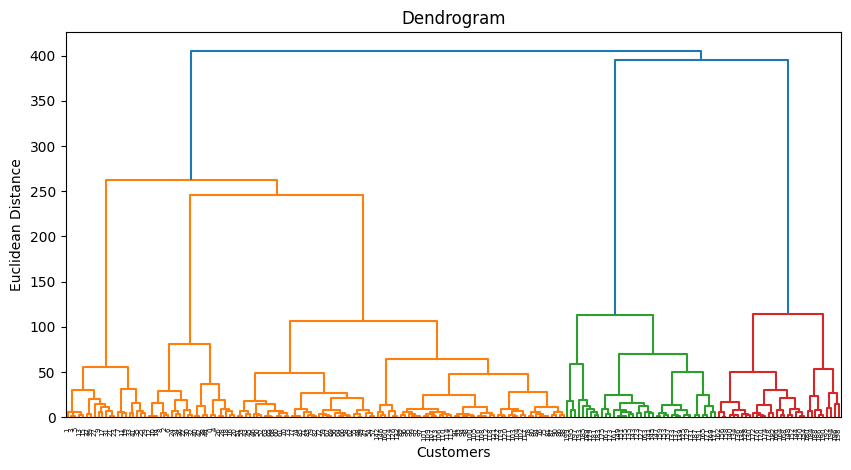

In [16]:
plt.figure(figsize=(10,5))

sch.dendrogram(
    sch.linkage(X, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [17]:
hc = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

y_hc = hc.fit_predict(X)

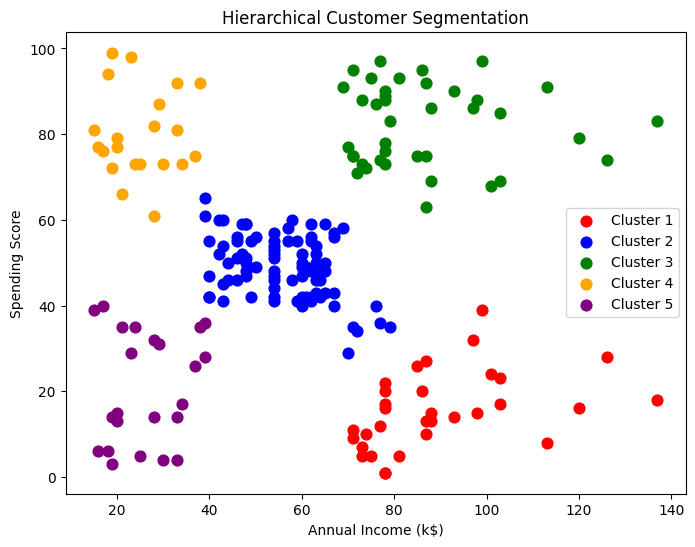

In [18]:
plt.figure(figsize=(8,6))

colors = ['red','blue','green','orange','purple']

for i in range(5):
    plt.scatter(
        X[y_hc == i,0],
        X[y_hc == i,1],
        s=60,
        color=colors[i],
        label=f'Cluster {i+1}'
    )

plt.title("Hierarchical Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.legend()

plt.show()

In [19]:
df["KMeans_Cluster"] = y_kmeans
df["Hierarchical_Cluster"] = y_hc

df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Hierarchical_Cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,4,4
5,6,Female,22,17,76,2,3
6,7,Female,35,18,6,4,4
7,8,Female,23,18,94,2,3
8,9,Male,64,19,3,4,4
9,10,Female,30,19,72,2,3


In [20]:
print("K-Means Cluster Counts")
print(df["KMeans_Cluster"].value_counts())

print()

print("Hierarchical Cluster Counts")
print(df["Hierarchical_Cluster"].value_counts())

K-Means Cluster Counts
KMeans_Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

Hierarchical Cluster Counts
Hierarchical_Cluster
1    85
2    39
0    32
4    23
3    21
Name: count, dtype: int64


In [21]:
summary = df.groupby("KMeans_Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

summary

,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [22]:
print("Customer Segmentation using K-Means and Hierarchical Clustering Completed Successfully!")

Customer Segmentation using K-Means and Hierarchical Clustering Completed Successfully!
